<a href="https://colab.research.google.com/github/IrisCheon/NLP-practice/blob/main/Disaster_Tweet_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Disaster Tweet Analysis

This project explores disaster-related tweet classification using TF-IDF with Logistic Regression and LinearSVC.

The analysis includes:
- basic EDA
- tweet length analysis
- keyword observations
- model comparison
- coefficient analysis
- error analysis

The goal of the project is not only to compare model performance, but also to observe how simple linear NLP models respond to ambiguous or context-dependent language.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

In [2]:
base_path = r'/content/drive/MyDrive/1. data/dataset/disaster_tweets'

train_df = pd.read_csv(os.path.join(base_path, "train.csv"))

# ■ 데이터 확인

In [3]:
train_df.head()

,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1


In [4]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7613 entries, 0 to 7612
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        7613 non-null   int64 
 1   keyword   7552 non-null   object
 2   location  5080 non-null   object
 3   text      7613 non-null   object
 4   target    7613 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 297.5+ KB


In [5]:
train_df.isnull().sum()

,0
id,0
keyword,61
location,2533
text,0
target,0


In [6]:
train_df["target"].value_counts()
# disaster가 아닌 트윗이 더 많음

,count
target,
0,4342
1,3271


In [8]:
train_df["keyword"].value_counts()

,count
keyword,
fatalities,45
deluge,42
armageddon,42
damage,41
body%20bags,41
...,...
forest%20fire,19
epicentre,12
threat,11


# ■ Text length

In [12]:
train_df["text_length"] = train_df["text"].str.len()
train_df["text_length"].describe()

,text_length
count,7613.000000
mean,101.037436
std,33.781325
min,7.000000
25%,78.000000
50%,107.000000
75%,133.000000
max,157.000000


In [15]:
train_df.groupby("target")["text_length"].mean()
# disaster tweet의 길이가 더 길다

,text_length
target,
0,95.706817
1,108.113421


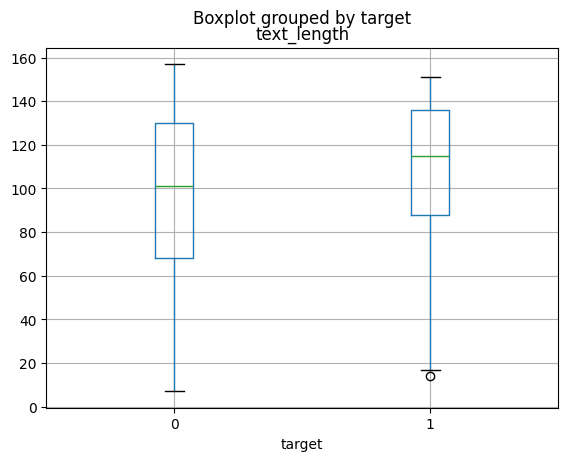

In [16]:
train_df.boxplot(column = "text_length", by = "target")
plt.show()
# disaster tweet의 표준편차가 더 작다 + outlier가 있음

# ■ Target

In [23]:
ct = pd.crosstab(train_df["keyword"], train_df["target"])
ct

target,0,1
keyword,,
ablaze,23,13
accident,11,24
aftershock,34,0
airplane%20accident,5,30
ambulance,18,20
...,...,...
wounded,11,26
wounds,23,10
wreck,30,7


In [32]:
ct["disaster_ratio"] = (ct[1] / (ct[0]+ct[1]))
ct.sort_values("disaster_ratio", ascending=False).head(20)

target,0,1,disaster_ratio
keyword,,,
derailment,0,39,1.000000
debris,0,37,1.000000
wreckage,0,39,1.000000
outbreak,1,39,0.975000
typhoon,1,37,0.973684
oil%20spill,1,37,0.973684
suicide%20bombing,1,32,0.969697
suicide%20bomber,1,30,0.967742
bombing,2,27,0.931034


In [34]:
ct.sort_values("disaster_ratio", ascending=True).head(20)

target,0,1,disaster_ratio
keyword,,,
aftershock,34,0,0.000000
body%20bags,40,1,0.024390
ruin,36,1,0.027027
blazing,33,1,0.029412
body%20bag,32,1,0.030303
electrocute,31,1,0.031250
screaming,34,2,0.055556
traumatised,33,2,0.057143
panicking,31,2,0.060606


In [28]:
ct["disaster_ratio"].mean()

np.float64(0.4248901532730262)

In [39]:
pd.set_option("display.max_colwidth", 150)

train_df[train_df["target"]==1]["text"].sample(10)

,text
7429,[#Latestnews] Police officer wounded suspect dead after exchanging shots: RICHMOND Va. (AP) ÛÓ A Richmond pol... http://t.co/ia1HnGnHVB
7337,Is LA at Risk for a Giant Wildfire? - Which Way L.A.? on KCRW http://t.co/6AgMkx2WW4
4552,@ChristieC733 please support this Please cosponsor S. 928 and support aid for sick and injured 9/11 responders! #renew911health
3422,@allen_enbot If you mess up it's gonna explode...
3288,Disaster control teams are studying ways to evacuate the port area in response to tidal wave warnings.[900037]
3005,There's a big storm brewing dark clouds thunder and rain carrying thick dust. This could be interesting.
398,RelaxInPR: miprv: RT latimes: Arson suspect linked to 30 fires caught in Northern California http://t.co/ylhAyfaOOu
5292,Families to sue over Legionnaires: More than 40 families affected by the fatal outbreak of Legionnaires' disease in Edinburgh are to ...
5717,WomanÛªs GPS app guides rescuers to injured biker in Marin County http://t.co/UoJy4E2Sv4
2343,Demolition Means Progress: Flint Michigan and the Fate of the American Metropolis Highsmith https://t.co/ZvoBMDxHGP


In [40]:
train_df[train_df["target"]==0]["text"].sample(10)

,text
6863,Both kids got haircuts w minimal trauma. Clearly that calls for wine
4190,Davis's Drug Guide for Nurses by Judith Hopfer Deglin and April Hazard Vallerand http://t.co/IufS7UV1HK http://t.co/AFrHnLLY8D
6901,A traumatised dog that was found buried up to its head in dirt in France is now in safe hands. This is such a... http://t.co/AGQo1479xM
5902,PUT SANDSTORM DOWN!!!! https://t.co/EfKCoegJck
2668,Detonate (feat. M.O.P.) by Apollo Brown http://t.co/h9FSIaxv3Q
5849,fresh out da shower lookss ?? (still loving this new hair does it ruin my brand?) #yes https://t.co/T2Kk8fya77
1250,So my band Buildings on Fire are playing @bbcintroducing @PurpleTurtleRdg this Wednesday with @GIANTGIANTSOUND https://t.co/ofaN6DkOEZ #rdg
2617,Russian authorities to take account of petition against destruction of sanctioned food: Vladimir Putin's press... http://t.co/QbMcSJaVt0
4891,@eileenmfl are you serious?
1942,Rite now man a tlk widout nuh curfew long side Aka cum fi steal di show itz a rubbery di whole a dem fi knw... Sound it *music*


# ■ Logistic Regression

In [48]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    train_df["text"],
    train_df["target"],
    test_size=0.2,
    random_state=42
)

In [49]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [50]:
vectorizer = TfidfVectorizer(
    stop_words = "english",
    max_features = 5000,
    ngram_range = (1, 2)
)

In [54]:
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

In [53]:
from sklearn.linear_model import LogisticRegression

In [59]:
model = LogisticRegression(
    max_iter = 100
)

In [60]:
model.fit(X_train_vec, y_train)
        # 벡터 변환한것을 넣어주기

LogisticRegression()

In [61]:
preds = model.predict(X_test_vec)
            # 벡터 변환한것 넣어주기

In [62]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

In [63]:
print(classification_report(y_test, preds))

              precision    recall  f1-score   support

           0       0.79      0.88      0.83       874
           1       0.81      0.69      0.75       649

    accuracy                           0.80      1523
   macro avg       0.80      0.78      0.79      1523
weighted avg       0.80      0.80      0.80      1523



              precision    recall  f1-score   support

           0       0.79      0.88      0.83       874
           1       0.81      0.69      0.75       649

    accuracy                           0.80      1523
    macro avg       0.80      0.78      0.79      1523
    weighted avg       0.80      0.80      0.80      1523

---


※ 전반적으로 점수가 다 낮지만, Positive recall이 상당히 떨어짐. 전반적으로 잘 분류하지는 못하는 것 같음
- Negative precision도 낮은 것을 보면, 전반적으로 0으로 분류하는 경향이 있는 듯

In [64]:
confusion_matrix(y_test, preds)

array([[766, 108],
       [199, 450]])

# ■ Feature Importance

In [65]:
feature_names = vectorizer.get_feature_names_out()

In [67]:
coefficients = model.coef_[0]
    # 단어별 가중치 가져오기

In [71]:
coef_df = pd.DataFrame({
    "word" : feature_names,
    "coef" : coefficients
}).sort_values("coef", ascending = False)

coef_df.head(20)

,word,coef
2225,hiroshima,3.299693
748,california,2.704193
1827,fires,2.546687
2492,killed,2.525546
1509,earthquake,2.482602
4186,suicide,2.426260
708,buildings,2.401924
4810,wildfire,2.278709
1901,forest,2.174196
632,bombing,2.115566


In [72]:
coef_df.sort_values("coef", ascending=True).head(20)

,word,coef
3022,new,-2.030377
2682,love,-1.671965
3251,panicking,-1.637205
2580,let,-1.611523
4902,wrecked,-1.604518
3791,ruin,-1.591628
3860,screaming,-1.585847
576,blight,-1.517933
521,better,-1.513493
3084,nowplaying,-1.457463


※ disaster tweets coef 상위 단어들 : 재난과 직접적인 연관 있는 단어 다수
- 감정 등 관련 단어는 의외로 잘 보이지 않음
- non-disaster tweets 단어들은 일반적인 단어 + 묘하게 감정/가치판단 쪽 단어 존재
- 연관성을 알 수 없으나, http는 disaster, https는 non-disaster인 것은 흥미로움

# ■ Error Analysis

In [74]:
results = pd.DataFrame({
    "text" : X_test,
    "actual" : y_test,
    "pred" : preds
})

results.sample(10)

,text,actual,pred
1919,Police: Teenagers arrested for curfew violations in Evanston were riding stolen bicycles: Two teenagers taken into cus... #Chicago #news,1,1
3121,It was a queer sultry summer the summer they electrocuted the Rosenbergs and I didn't know what I was doing in New York.,0,0
7003,Tornadoes: El Nino may give Canada's twister season a boost #Toronto http://t.co/agyCutKBnN,1,0
7239,WWII Memories Plus Lessons of Hiroshima We Still Need Nuclear Weapons http://t.co/xbMm7ITe9q #denver #billings #rapidcity #seattle #cheyenne,1,1
1429,Being able to stay out of work this week to take online courses for the Property and Casualty StateÛ_ https://t.co/jmD7zwKSDM,0,0
469,@CaIxxum5SOS thanks for the damn heart attack,0,1
1954,A new tropical cyclone is forming near Guam.\n\nOnce it is formed it will be called 'Molave'.,1,1
6435,@JewhadiTM It is almost amazing to think someone thought suicide bombing would actually be a good idea.,1,0
1210,@joshcorman #infosec rather you knew it or not your a firefighter now days you often run into burning buildings Deal with it.,0,1
547,STAR WARS POWER OF THE JEDI COLLECTION 1 BATTLE DROID HASBRO - Full read by eBay http://t.co/xFguklrlTf http://t.co/FeGu8hWMc4,1,0


In [77]:
errors = results[
    (results["actual"] != results["pred"])
]

errors.sample(10)

,text,actual,pred
1737,Cyclist who collided with runner on Roanoke greenway wins $300000 civil verdict - Roanoke Times: Cyclist who c... http://t.co/E2WfGp8JHk,1,0
7064,Upheaval high note for bush opera http://t.co/aWPU0gaE0b #Sydney #News #Aus,0,1
167,Statistically I'm at more of risk of getting killed by a cop than I am of dying in an airplane accident.,0,1
5045,First time getting into #gbbo2015 and physically gasped at the cake 'mudslide' incident already way too emotionally invested...,1,0
7359,Windstorm lastingness perquisite - acquiesce in a twister retreat: ZiUW http://t.co/iRt4kkgsJx,1,0
7050,I think a Typhoon just passed through here lol,1,0
7150,@volcano_tornado live somewhere else for a while and Da Mill ain't too bad son! #perspective,1,0
445,Big Top Burning The True Story Of An Arsonist A Missing Girl Û_ : http://t.co/QxH1H61cwD .,1,0
5077,Patriot Survival Guide: Do you know how survive when the governments collapse or other natural disaster happens? http://t.co/QhtoerhDkM,1,0
7145,@alextucker VOLCANO BOWL DRINK,1,0


In [80]:
errors["text_lengths"] = errors["text"].str.len()
errors.head()

/tmp/ipykernel_2903/3069976569.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  errors["text_lengths"] = errors["text"].str.len()


,text,actual,pred,text_lengths
2644,So you have a new weapon that can cause un-imaginable destruction.,1,0,66
1765,my favorite lady came to our volunteer meeting\nhopefully joining her youth collision and i am excite http://t.co/Ij0wQ490cS,1,0,123
1817,@brianroemmele UX fail of EMV - people want to insert and remove quickly like a gas pump stripe reader. 1 person told me it crashed the POS,1,0,139
3044,Nepal earthquake 3 months on: Women fear abuse https://t.co/iCTtZ0Divr via @@loupascale,1,0,87
2534,Escape The Heat (and the #ORShow) for a trail run on Desolation Loop you'll be glad you did http://t.co/n2ucNzh38P http://t.co/VU8fWYMw5r,0,1,137


In [81]:
errors_FN = errors[errors["actual"]==1]
errors_FN.sample(10)

,text,actual,pred,text_lengths
2569,(SJ GIST): 148 Houses Farm Produce Destroy... http://t.co/dkrGS2AWEX #StreetjamzDotNet | https://t.co/mR9KcGpIwM,1,0,112
625,CDC has a pretty cool list of all bioterrorism agents :3,1,0,56
535,Chiasson Sens can't come to deal #ColoradoAvalanche #Avalanche http://t.co/2bk7laGMa9 http://t.co/bkDGCfsuiQ,1,0,108
5470,Reddit Will Now Quarantine Offensive Content http://t.co/WosYPVQUFI http://t.co/XW8SDS1Tjp,1,0,90
1533,???? #Krefeld: the incident happened in a chemical industry park! Emergency operations underway! A building reportly collapsed! @cnnbrk @ntvde,1,0,142
3550,exporting food wont solve the problem. africans will end famine n poverty by SOLVING OUT OF CONTROL TRIBAL WARS. https://t.co/UttaNbigRx,1,0,136
733,@KatRamsland Yes I'm a bleeding heart liberal.,1,0,46
4713,Imagine a room with walls that are lava lamps.,1,0,46
7278,Two hours to get to a client meeting. Whirlwind of emotions with this #tubestrike,1,0,81
6513,A country Chim can survive!,1,0,27


In [82]:
errors_FP = errors[errors["actual"]==0]
errors_FP.sample(10)

,text,actual,pred,text_lengths
5459,#helpme what do I do? My friend has been ticketed by Police in Wayne County Michigan into never- sending poverty cycle. How do I help him?,0,1,138
6587,Survivors of Shanghai Ghetto reunite after 70 years - http://t.co/1Ki8LgVAy4 #Shanghai #China #??,0,1,97
696,Why Some Traffic Is Freezing Cold And Some Blazing Hot ÛÒ And How To Heat Up Some Of Your Traffic http://t.co/C8b6DdiQIg,0,1,121
6046,Sinkhole Selfies: You Wont Believe What's In The Brooklyn Sinkhole!: \n Sinkhole Selfies: You Wont Belie... http://t.co/A3b5n3rcr5,0,1,136
6361,@FoxNewsInsider All Obama is doing is giving a false time schedule on Iran testing there first bomb Bomb = Nuclear Suicide Vest,0,1,132
3979,@kwislo I see her flooding at mad decent,0,1,40
7317,Man selling WILD MORELS at Ambleside Farmr Mart.Sun.-MUSHROOM forageSECRET IS TO KNOW WHAT TREES they grow under &amp; BEST AFTER FOREST FIRES,0,1,142
6608,Does this apply to Muslims/terrorism?\nOr Catholicism/homophobia?,0,1,64
3560,A grade in Black Horse Famine[MEGA]. Score 0840728\nhttp://t.co/pdiit0AF3Q\n#Dynamix http://t.co/ZQ5KDOx7BY,0,1,105
1421,Stay tuned or don't idc #casualties http://t.co/nssjPR6Pdd,0,1,58


※ FP : 특정 단어에 꽂힌 것 같음(forest fire, death, earthquake...)
- 역으로 FN은 재난 관련 단어가 직접적으로 언급되지 않는 편

In [85]:
print("Text_length: ", results["text"].str.len().mean())

print("FN: ", errors_FN["text_lengths"].mean())
print("FP: ", errors_FP["text_lengths"].mean())

Text_length:  100.92317793827971
FN:  102.94974874371859
FP:  93.54629629629629


※ FN의 글자수 길이는 전체와 큰 차이가 없지만, FP는 10자 가량(10%) 더 짧음
- 모델이 0 쪽으로 더 분류하는 성향을 갖고 있었는데도 FP가 발생하였다는 것은
- 텍스트가 짧은 와중에도(판단할 재료가 부족한 상황에도) 강한 시그널을 주는 단어가 있었기 떄문으로 추정
    - 그렇기 때문에 명시적인 재난 관련 단어들(coef가 높은)이 포함된 것으로 추정

# ■ LinearSVC

In [86]:
from sklearn.svm import LinearSVC

svc_model = LinearSVC()
svc_model.fit(X_train_vec, y_train)

svc_preds = svc_model.predict(X_test_vec)

print(classification_report(y_test, svc_preds))
print(confusion_matrix(y_test, svc_preds))

              precision    recall  f1-score   support

           0       0.80      0.82      0.81       874
           1       0.75      0.72      0.74       649

    accuracy                           0.78      1523
   macro avg       0.78      0.77      0.78      1523
weighted avg       0.78      0.78      0.78      1523

[[721 153]
 [179 470]]


- LR

          precision    recall  f1-score   support

       0       0.79      0.88      0.83       874
       1       0.81      0.69      0.75       649

- SVC

              precision    recall  f1-score   support

           0       0.80      0.82      0.81       874
           1       0.75      0.72      0.74       649


※ 성능 자체는 큰 차이 없지만, positive recall은 일부 개선된 것 같음. LR이 SVC보다 더 보수적임

In [95]:
feature_names = vectorizer.get_feature_names_out()

svc_coef_df = pd.DataFrame({
    "word": feature_names,
    "coef": svc_model.coef_[0]
})

In [96]:
svc_coef_df.sort_values("coef", ascending=False).head(20)

,word,coef
2225,hiroshima,2.466078
3748,riots,2.450276
1301,derailment,2.196289
4810,wildfire,2.194510
1509,earthquake,2.103252
708,buildings,2.067744
748,california,1.997200
1901,forest,1.925381
2750,massacre,1.826067
2818,michigan,1.779088


In [97]:
svc_coef_df.sort_values("coef", ascending=True).head(20)

,word,coef
521,better,-1.591302
4445,train wreck,-1.508344
743,cake,-1.418801
332,anti,-1.319114
1070,cook,-1.316779
3084,nowplaying,-1.312620
623,bomb ass,-1.304651
4909,wrong,-1.303695
4860,wont,-1.302181
2462,join,-1.278444


※ coef 상위 단어들은 큰 차이 없는 것 같지만, 하위 단어들에서 lr보다 일반적인 단어들이 더 자주 등장하는 것으로 보임
- lr은 disaster 관련된것으로 볼 여지 있는 것들(harm 등)도 등장했음

# ■ LR - SVC 비교

In [92]:
compare_df = pd.DataFrame({
    "text": X_test,
    "actual": y_test,
    "lr_pred": preds,
    "svc_pred": svc_preds
})

compare_df.head()

,text,actual,lr_pred,svc_pred
2644,So you have a new weapon that can cause un-imaginable destruction.,1,0,0
2227,The f$&amp;@ing things I do for #GISHWHES Just got soaked in a deluge going for pads and tampons. Thx @mishacollins @/@,0,0,0
5448,DT @georgegalloway: RT @Galloway4Mayor: ÛÏThe CoL police can catch a pickpocket in Liverpool Stree... http://t.co/vXIn1gOq4Q,1,1,1
132,Aftershock back to school kick off was great. I want to thank everyone for making it possible. What a great night.,0,0,0
6845,in response to trauma Children of Addicts develop a defensive self - one that decreases vulnerability. (3,0,0,0


In [93]:
different_preds = compare_df[
    compare_df["lr_pred"] != compare_df["svc_pred"]
]

different_preds.sample(10)

,text,actual,lr_pred,svc_pred
2495,@joshacagan Your only option now is to move to an desolate island with nothing but a stack of DVDs you canÛªt watch.,0,0,1
4535,Arian Foster does keep his promise... And that's to get injured every yeat,0,0,1
2676,@SourMashNumber7 @tomfromireland @rfcgeom66 @BBCTalkback They didn't succeed the other two times either. Bomb didn't detonate&amp;Shots missed.,1,0,1
6237,you're the snowstorm I'm purified. the darkest fairy tale in the pale moonlight.,0,0,1
2678,Apollo Brown ÛÒ Detonate ft.åÊM.O.P. http://t.co/JD7rIK7fX0 http://t.co/h6NgSw9A5b,0,0,1
2874,@KarinaGarciaxo_ me &amp; you both &amp; I'll be dam if I get any of that drought bud,0,0,1
4379,RT NotExplained: The only known image of infamous hijacker D.B. Cooper. http://t.co/JlzK2HdeTG,0,0,1
6540,@TheSmallClark 'He'll kill me instead if he survived the shot. I don't exactly know. I fled the scene and pulled the trigger with---,1,0,1
3355,Good thing there was actually just a legit fire in the mall and nobody evacuated!!,1,0,1
2913,Don't think for one second I'm out to drown your memory. Baby you ain't worth the whiskey.,0,0,1


`2678	Apollo Brown ÛÒ Detonate ft.åÊM.O.P. http://t.co/JD7rIK7fX0 http://t.co/h6NgSw9A5b`

별 내용 없는 위 텍스트를 lr은 0, svc는 1로 예측(actual = 0)
- svc가 lr보다 더 쉽게 1로 판단한다

In [94]:
both_wrong = compare_df[
    (compare_df["lr_pred"] != compare_df["actual"]) &
    (compare_df["svc_pred"] != compare_df["actual"])
]

both_wrong.sample(10)

,text,actual,lr_pred,svc_pred
696,Why Some Traffic Is Freezing Cold And Some Blazing Hot ÛÒ And How To Heat Up Some Of Your Traffic http://t.co/C8b6DdiQIg,0,1,1
3058,Earthquake drill ??????,0,1,1
2970,@HeyImBeeYT its like theres fire in my skin and im drowning from within ????,1,0,0
5950,@camilacabello97 Internally and externally screaming,1,0,0
3515,Interesting approach but doesn't replace Eyewitness video. The Ferguson Case - Video - http://t.co/vEcsoSRleR http://t.co/fiUOgj6hEF,1,0,0
469,@CaIxxum5SOS thanks for the damn heart attack,0,1,1
425,Video Captures Man Removing American Flag From Long Beach CA Home Burning It; Arsonist Sought http://t.co/JP2QlrunjJ http://t.co/jbpgkGOwSi,0,1,1
2986,Drowning in Actavis suicide,0,1,1
1451,Canceling Deal for 2 Warships #France Agrees to Repay #Russia via @nytimes http://t.co/f2gwxEPrAk,0,1,1
3254,@godsfirstson1 and she wrapped his coat around herself. It practically engulfed her.,1,0,0


`2970	@HeyImBeeYT its like theres fire in my skin and im drowning from within ????`

`2986	Drowning in Actavis suicide	`

둘 다 'drowning'이 있는데, 2970은 둘다 0으로 예측, 2986은 둘다 1로 예측한 것이 독특
- drowning의 coef가 상대적으로 낮은 것 아닐지?

# ■ Conclusion

# Conclusion

Most tweets in the dataset were relatively short, and disaster tweets showed a smaller length variance compared to non-disaster tweets.

Logistic Regression showed a relatively conservative prediction tendency, with lower positive recall and more frequent predictions toward the non-disaster class. False positive tweets were slightly shorter on average, suggesting that some short tweets containing strong disaster-related keywords may have triggered positive predictions despite limited context.

Coefficient analysis showed that highly positive coefficients were mostly associated with directly disaster-related words. For lower coefficients, Logistic Regression still included some potentially disaster-related words such as "harm", while LinearSVC tended to contain more general or common words in its lower-ranked coefficients.

LinearSVC produced slightly higher positive recall and appeared less conservative overall, although the overall performance difference between the two models was not large.

Error analysis also showed several cases where the models relied heavily on keywords without fully understanding context. For example, tweets containing words such as "drowning" could be classified differently depending on surrounding text and tweet structure.